# QM9 Reproducible Data Workflow

**Capstone 1 — Building a clean, reproducible data workflow**

This notebook loads, cleans, explores, visualizes, and communicates findings on the
**QM9** dataset (133,885 small organic molecules with 15 quantum-chemical properties
computed at the B3LYP/6-31G(2df,p) level of theory).

**Dataset source:** Ramakrishnan, R., Dral, P. O., Rupp, M., & von Lilienfeld, O. A. (2014).
*Quantum chemistry structures and properties of 134 kilo molecules.* Scientific Data, 1, 140022.
Figshare collection 978904.

## About the Dataset (plain-English overview)

**QM9** is a benchmark dataset in computational chemistry and machine learning. It
describes **133,885 small organic molecules** — the kind of building blocks found in
everyday chemistry — each made from just a handful of atoms drawn from **hydrogen (H),
carbon (C), nitrogen (N), oxygen (O), and fluorine (F)**, with up to **9 "heavy"
(non-hydrogen) atoms**.

Crucially, these molecules were **not measured in a lab**. Each one was **simulated on a
computer** using *quantum chemistry* — specifically DFT (density functional theory), at
the "B3LYP/6-31G(2df,p)" level, which is simply the name of the calculation recipe and
its accuracy setting. For every molecule the simulation produces:

- its **most stable 3D shape** (where each atom sits in space),
- a set of **15 physical and chemical properties** (energies, how the molecule responds
  to electric fields, how much heat it stores, and more),
- its **vibrations** (the ways the molecule flexes), and
- standard text **identifiers** (SMILES / InChI — compact strings that encode the
  molecule's structure).

**Why it matters.** Running these quantum simulations is slow and expensive. QM9 packages
the results for ~134k molecules so researchers can instead **train machine-learning
models to predict these properties in milliseconds** — a foundation for drug discovery,
materials design, and the kind of graph neural networks this workflow is meant to feed
into later. The next sections define every column in plain language, then load the data.

## 0. Environment & Reproducibility

Record the exact runtime and library versions so the analysis can be reproduced.
A fixed random seed is set for any later sampling/splitting steps.

In [11]:
import sys
import platform
import random

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility: one seed for the whole notebook
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Consistent plotting defaults
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100

print("Python      :", sys.version.split()[0], "(", platform.platform(), ")")
print("NumPy       :", np.__version__)
print("pandas      :", pd.__version__)
print("matplotlib  :", matplotlib.__version__)
print("seaborn     :", sns.__version__)
print("Random seed :", RANDOM_SEED)

Python      : 3.14.6 ( Windows-11-10.0.26200-SP0 )
NumPy       : 2.5.0
pandas      : 3.0.3
matplotlib  : 3.11.0
seaborn     : 0.13.2
Random seed : 42


## 1. Project Paths

Define paths relative to the project root so the notebook runs the same on any machine.

In [12]:
from pathlib import Path

# Resolve the project root whether the notebook runs from notebooks/ or the repo root.
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "reports" / "figures"

for p in (DATA_RAW, DATA_PROCESSED, FIGURES):
    p.mkdir(parents=True, exist_ok=True)

# Print paths relative to the project root so no machine-specific (home/username)
# paths are baked into the committed notebook output.
print("Project root :", PROJECT_ROOT.name)
print("Raw data     :", DATA_RAW.relative_to(PROJECT_ROOT).as_posix())
print("Processed    :", DATA_PROCESSED.relative_to(PROJECT_ROOT).as_posix())
print("Figures      :", FIGURES.relative_to(PROJECT_ROOT).as_posix())

Project root : Capstone2
Raw data     : data/raw
Processed    : data/processed
Figures      : reports/figures


## 2. Dataset Description & Data Dictionary

We ingest the **complete** QM9 record into four tables, all keyed by a molecule index
(`mol_id`). Every column is defined below in plain language. *Units in parentheses* use
standard quantum-chemistry conventions: **Ha** = Hartree (an atomic unit of energy),
**a₀** = Bohr radius (an atomic unit of length), **D** = Debye (a unit of dipole), and
**Å** = ångström (0.1 nm).

#### `qm9` — one row per molecule (the main table)

| Column | Plain-English meaning | Unit |
|---|---|---|
| `mol_id` | Unique molecule index (1…133,885); the key that links all four tables. | — |
| `n_atoms` | Total number of atoms in the molecule, including hydrogens. | count |
| `A`, `B`, `C` | Rotational constants — describe how the molecule's mass is spread out as it tumbles in space. | GHz |
| `mu` (μ) | Dipole moment — how electrically lopsided (polar) the molecule is. | Debye |
| `alpha` (α) | Isotropic polarizability — how easily the electron cloud distorts in an electric field. | a₀³ |
| `homo` | Energy of the highest occupied molecular orbital — how readily the molecule gives up an electron. | Ha |
| `lumo` | Energy of the lowest unoccupied molecular orbital — how readily it accepts an electron. | Ha |
| `gap` | The HOMO–LUMO gap (`lumo − homo`) — relates to stability, reactivity, and which light it absorbs. | Ha |
| `r2` (⟨R²⟩) | Electronic spatial extent — how spread out the electron cloud is (a size measure). | a₀² |
| `zpve` | Zero-point vibrational energy — residual vibration the molecule keeps even at absolute zero. | Ha |
| `u0` | Internal energy at 0 K. | Ha |
| `u` | Internal energy at 298.15 K (room temperature). | Ha |
| `h` | Enthalpy at 298.15 K (heat content at constant pressure). | Ha |
| `g` | Gibbs free energy at 298.15 K (energy available to do useful work). | Ha |
| `cv` | Heat capacity at 298.15 K — how much heat is needed to raise the molecule's temperature. | cal/(mol·K) |
| `is_uncharacterized` | Cleaning flag added in §4: `True` for the 3,054 molecules whose relaxed geometry is inconsistent with the original structure. | bool |

#### `qm9_atoms` — one row per atom (the 3D structure)

| Column | Plain-English meaning | Unit |
|---|---|---|
| `mol_id` | The molecule this atom belongs to. | — |
| `atom_idx` | The atom's position number within the molecule (0-based). | — |
| `element` | Chemical element symbol (H, C, N, O, or F). | — |
| `x`, `y`, `z` | The atom's coordinates in 3D space. | Å |
| `charge` | Mulliken partial charge — roughly, the share of electrons sitting on this atom. | e (electron charge) |

#### `qm9_frequencies` — one row per vibration (how the molecule flexes)

| Column | Plain-English meaning | Unit |
|---|---|---|
| `mol_id` | The molecule this vibration belongs to. | — |
| `mode_idx` | The vibration's number within the molecule (0-based). | — |
| `freq` | Harmonic vibrational frequency — the "pitch" of one way the molecule oscillates. | cm⁻¹ |

*Accuracy caveat:* `freq` values are **harmonic** frequencies (B3LYP/6-31G(2df,p)) given
as wavenumbers (cm⁻¹), with **no intensities**. They run systematically **~3–4% high**
versus experiment — most for X–H stretches — so they are reliable for trends, ML targets,
and qualitative mode assignment, but **not** for precise spectral-line positions.

#### `qm9_identifiers` — one row per molecule (text names for the structure)

| Column | Plain-English meaning |
|---|---|
| `mol_id` | The molecule. |
| `smiles_gdb17` | SMILES string from the original GDB-17 database (the input structure). |
| `smiles_relaxed` | SMILES re-derived from the simulated, relaxed 3D geometry. |
| `inchi_gdb17` | InChI string for the original structure. |
| `inchi_relaxed` | InChI for the relaxed geometry. |

<br>

> **SMILES** and **InChI** are compact text encodings of a molecule's structure — like a
> standardized spelling of the molecule. Comparing the *original* (`gdb17`) against the
> *relaxed* version is exactly what flags the 3,054 "uncharacterized" molecules in §4.

<br>

> **No spectra or wavelengths.** QM9 contains computed scalar properties, 3D geometries,
> and harmonic vibrational frequencies — *not* measured spectra, and no wavelengths or
> IR/UV intensities. The nearest spectroscopic ingredients are `freq` (vibrational mode
> positions; convert to IR wavelength via λ[µm] = 10⁴ ⁄ ν̃[cm⁻¹]), the rotational
> constants `A`/`B`/`C` (microwave transition frequencies), and `gap` (a rough proxy for
> the lowest electronic excitation). All are B3LYP computations — descriptors, not lab
> measurements.

## 3. Data Ingestion

Each QM9 `.xyz` file holds more than the 15 scalar properties — it also contains the
3D geometry, per-atom Mulliken charges, harmonic vibrational frequencies, and the
SMILES/InChI identifiers (Ramakrishnan et al., *Sci. Data* **1**, 140022, 2014). To
support querying **all** of this (SQL-like, via pandas joins on `mol_id`), we parse the
full record into a small **relational set** of tables, all keyed by `mol_id`:

| Table | Grain | Columns |
|---|---|---|
| `qm9` | one row per molecule | `n_atoms` + the 15 scalar properties |
| `qm9_atoms` | one row per atom | `mol_id, atom_idx, element, x, y, z, charge` |
| `qm9_frequencies` | one row per vibrational mode | `mol_id, mode_idx, freq` |
| `qm9_identifiers` | one row per molecule | `mol_id, smiles_*, inchi_*` |

Ingestion here is a **faithful** parse — it captures the files exactly as written,
including any raw-data quirks. Corrections (e.g. the duplicated-frequency lines found
in a small fraction of files) are applied and documented later, in **§4 Cleaning**.
The parsed tables are cached under `data/processed/` so the ~20-minute parse runs once.

In [13]:
# The 15 scalar properties stored on line 2 of each QM9 .xyz file (in order),
# per Ramakrishnan et al., Sci. Data 1, 140022 (2014).
PROPERTY_NAMES = [
    "A", "B", "C", "mu", "alpha", "homo", "lumo", "gap",
    "r2", "zpve", "u0", "u", "h", "g", "cv",
]


def _to_float(token: str) -> float:
    """Convert a QM9 numeric token, handling Fortran-style exponents like ``1.2*^-6``."""
    return float(token.replace("*^", "e"))


def parse_qm9_xyz(path):
    """Parse one QM9 .xyz file into its full record (faithful — no corrections here).

    File layout (Ramakrishnan et al., 2014), for a molecule with ``n`` atoms:
      line 1            : n (atom count)
      line 2            : "gdb <mol_id>" + the 15 scalar properties
      lines 3 .. n+2    : per-atom  ->  element, x, y, z, Mulliken charge
      line n+3          : harmonic vibrational frequencies (3n-6, or 3n-5 if linear)
      line n+4          : SMILES (GDB-17 string, then B3LYP-relaxed string)
      line n+5          : InChI  (GDB-17 string, then B3LYP-relaxed string)

    Returns
    -------
    (scalars, atoms, freqs, identifiers)
        scalars     : dict  -> one molecule row (mol_id, n_atoms, 15 properties)
        atoms       : list[dict] -> one row per atom
        freqs       : list[float] -> vibrational frequencies, as written in the file
        identifiers : dict  -> SMILES / InChI strings
    """
    lines = path.read_text().splitlines()
    n_atoms = int(lines[0])
    header = lines[1].split()  # ["gdb", <mol_id>, <15 properties...>]
    mol_id = int(header[1])

    scalars = {"mol_id": mol_id, "n_atoms": n_atoms}
    scalars.update(zip(PROPERTY_NAMES, (_to_float(t) for t in header[2:17])))

    atoms = []
    for atom_idx, line in enumerate(lines[2:2 + n_atoms]):
        element, x, y, z, charge = line.split()
        atoms.append({
            "mol_id": mol_id, "atom_idx": atom_idx, "element": element,
            "x": _to_float(x), "y": _to_float(y), "z": _to_float(z),
            "charge": _to_float(charge),
        })

    freqs = [_to_float(t) for t in lines[2 + n_atoms].split()]

    smiles = lines[3 + n_atoms].split()
    inchi = lines[4 + n_atoms].split()
    identifiers = {
        "mol_id": mol_id,
        "smiles_gdb17": smiles[0], "smiles_relaxed": smiles[-1],
        "inchi_gdb17": inchi[0], "inchi_relaxed": inchi[-1],
    }

    return scalars, atoms, freqs, identifiers

In [14]:
# Parsing all ~133k .xyz files is slow (~20 min), so cache the four tables and reuse
# them. On later runs we just load the CSVs. Delete them to force a fresh re-parse.
CACHE = {
    "qm9": DATA_PROCESSED / "qm9_properties.csv",
    "atoms": DATA_PROCESSED / "qm9_atoms.csv",
    "frequencies": DATA_PROCESSED / "qm9_frequencies.csv",
    "identifiers": DATA_PROCESSED / "qm9_identifiers.csv",
}

if all(p.exists() for p in CACHE.values()):
    qm9 = pd.read_csv(CACHE["qm9"], index_col="mol_id")
    qm9_atoms = pd.read_csv(CACHE["atoms"])
    qm9_frequencies = pd.read_csv(CACHE["frequencies"])
    qm9_identifiers = pd.read_csv(CACHE["identifiers"], index_col="mol_id")
    print("Loaded cached tables:")
    for p in CACHE.values():
        print(f"  {p.relative_to(PROJECT_ROOT).as_posix()}")
else:
    XYZ_DIR = DATA_RAW / "dsgdb9nsd"
    xyz_files = sorted(XYZ_DIR.glob("dsgdb9nsd_*.xyz"))
    print(f"No complete cache found - parsing {len(xyz_files):,} .xyz files (~20 min) ...")

    scalar_records, atom_records, freq_records, id_records = [], [], [], []
    for path in xyz_files:
        scalars, atoms, freqs, identifiers = parse_qm9_xyz(path)
        scalar_records.append(scalars)
        atom_records.extend(atoms)
        freq_records.extend(
            {"mol_id": scalars["mol_id"], "mode_idx": i, "freq": v}
            for i, v in enumerate(freqs)
        )
        id_records.append(identifiers)

    qm9 = pd.DataFrame.from_records(scalar_records).sort_values("mol_id")
    assert qm9["mol_id"].is_unique, "mol_id is not unique; cannot use it as the index"
    qm9 = qm9.set_index("mol_id")
    qm9_atoms = pd.DataFrame.from_records(atom_records)
    qm9_frequencies = pd.DataFrame.from_records(freq_records)
    qm9_identifiers = pd.DataFrame.from_records(id_records).set_index("mol_id")

    qm9.to_csv(CACHE["qm9"], index_label="mol_id")
    qm9_atoms.to_csv(CACHE["atoms"], index=False)
    qm9_frequencies.to_csv(CACHE["frequencies"], index=False)
    qm9_identifiers.to_csv(CACHE["identifiers"], index_label="mol_id")
    print("Parsed and cached four tables under data/processed/.")

print(
    f"\nqm9             : {qm9.shape[0]:,} molecules x {qm9.shape[1]} columns"
    f"\nqm9_atoms       : {len(qm9_atoms):,} atom rows"
    f"\nqm9_frequencies : {len(qm9_frequencies):,} mode rows"
    f"\nqm9_identifiers : {len(qm9_identifiers):,} molecules"
)
qm9.head()

Loaded cached tables:
  data/processed/qm9_properties.csv
  data/processed/qm9_atoms.csv
  data/processed/qm9_frequencies.csv
  data/processed/qm9_identifiers.csv

qm9             : 133,885 molecules x 16 columns
qm9_atoms       : 2,407,753 atom rows
qm9_frequencies : 6,438,713 mode rows
qm9_identifiers : 133,885 molecules


,n_atoms,A,B,C,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv
mol_id,,,,,,,,,,,,,,,,
1,5,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469
2,4,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316
3,3,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002
4,4,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,59.5248,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574
5,3,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,48.7476,0.016601,-93.411888,-93.409370,-93.408425,-93.431246,6.278


## 4. Data Cleaning & Transformation

First a "first look" (shape, dtypes, cardinality, summary stats), then a validation
suite that asserts the assumptions the analysis relies on. Findings and decisions are
documented inline as we go: the 29 duplicate scalar-property rows (kept, explained),
and the duplicated-frequency-line anomaly (corrected here). The ~3,054 molecules that
failed QM9's geometric-consistency check are handled as a separate, explicit decision.

In [15]:
# Initial inspection ("first look") before cleaning.
# These outputs guide the cleaning decisions that follow.

# 1. Dimensions
print(f".shape -> {qm9.shape[0]:,} rows x {qm9.shape[1]} columns\n")

# 2. Column data types
print(".dtypes ->")
print(qm9.dtypes)


.shape -> 133,885 rows x 16 columns

.dtypes ->
n_atoms      int64
A          float64
B          float64
C          float64
mu         float64
alpha      float64
homo       float64
lumo       float64
gap        float64
r2         float64
zpve       float64
u0         float64
u          float64
h          float64
g          float64
cv         float64
dtype: object


In [16]:
# 3. Unique values per column (spot constants / ID-like / low-cardinality columns)
print(".nunique() ->")
print(qm9.nunique())


.nunique() ->
n_atoms        26
A          108881
B           89131
C           76995
mu          50463
alpha        5457
homo         1828
lumo         2422
gap          2705
r2         132695
zpve        73488
u0         132396
u          132462
h          132445
g          132456
cv          20142
dtype: int64


In [17]:
# 4. Structure + non-null counts (missing-value check)
print(".info() ->")
qm9.info()


.info() ->
<class 'pandas.DataFrame'>
RangeIndex: 133885 entries, 1 to 133885
Data columns (total 16 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   n_atoms  133885 non-null  int64  
 1   A        133885 non-null  float64
 2   B        133885 non-null  float64
 3   C        133885 non-null  float64
 4   mu       133885 non-null  float64
 5   alpha    133885 non-null  float64
 6   homo     133885 non-null  float64
 7   lumo     133885 non-null  float64
 8   gap      133885 non-null  float64
 9   r2       133885 non-null  float64
 10  zpve     133885 non-null  float64
 11  u0       133885 non-null  float64
 12  u        133885 non-null  float64
 13  h        133885 non-null  float64
 14  g        133885 non-null  float64
 15  cv       133885 non-null  float64
dtypes: float64(15), int64(1)
memory usage: 16.3 MB


In [18]:
# 5. Summary statistics (rendered as a table below)
qm9.describe()


,n_atoms,A,B,C,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv
count,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000,133885.000000
mean,17.983740,9.814382,1.406097,1.124921,2.706037,75.191296,-0.239977,0.011124,0.251100,1189.527450,0.148524,-411.543985,-411.535513,-411.534569,-411.577397,31.600676
std,2.954258,1809.465666,1.583795,1.095618,1.530394,8.187793,0.022131,0.046936,0.047519,279.757172,0.033274,40.060230,40.060012,40.060012,40.060741,4.062471
min,3.000000,0.000000,0.337120,0.331180,0.000000,6.310000,-0.428600,-0.175000,0.024600,19.000200,0.015951,-714.568061,-714.560153,-714.559209,-714.602138,6.002000
25%,16.000000,2.554430,1.091630,0.910480,1.588700,70.380000,-0.252500,-0.023800,0.216300,1018.322600,0.125289,-437.913936,-437.905942,-437.904997,-437.947682,28.942000
50%,18.000000,3.090360,1.369940,1.078560,2.500000,75.500000,-0.241000,0.012000,0.249400,1147.585800,0.148329,-417.864758,-417.857351,-417.856407,-417.895731,31.555000
75%,20.000000,3.835820,1.653980,1.279540,3.636100,80.520000,-0.228700,0.049200,0.288200,1308.816600,0.171150,-387.049166,-387.039746,-387.038802,-387.083279,34.276000
max,29.000000,619867.683140,437.903860,282.945450,29.556400,196.620000,-0.101700,0.193500,0.622100,3374.753200,0.273944,-40.478930,-40.476062,-40.475117,-40.498597,46.969000


In [19]:
# Data validation: check the parsed table's assumptions, without presuming
# the outcome -- the data may or may not need corrective action.
# Hard checks FAIL loudly if an assumption is violated; observations record
# dataset characteristics worth flagging but not asserting. (This examines
# data quality only; the ~3,054 geometry-flagged molecules are handled separately.)
EXPECTED_N = 133_885                           # documented QM9 size (Ramakrishnan et al., 2014)
EXPECTED_COLS = ["n_atoms"] + PROPERTY_NAMES   # n_atoms + the 15 scalar properties

checks = []        # (name, passed, detail) -- hard guarantees, asserted at the end
observations = []  # (name, detail)         -- expected quirks, reported only


def check(name, passed, detail=""):
    checks.append((name, bool(passed), detail))


def observe(name, detail=""):
    observations.append((name, detail))


# 1. Completeness: no missing values; full expected row count.
n_missing = int(qm9.isna().sum().sum())
check("1. No missing values", n_missing == 0, f"{n_missing} NaNs")
check("1. Row count == 133,885", len(qm9) == EXPECTED_N, f"{len(qm9):,} rows")
xyz_dir = DATA_RAW / "dsgdb9nsd"
if xyz_dir.exists():
    n_xyz = sum(1 for _ in xyz_dir.glob("dsgdb9nsd_*.xyz"))
    check("1. Rows == .xyz file count", len(qm9) == n_xyz, f"{n_xyz:,} files")

# 2. Key integrity: mol_id unique and a contiguous 1..N index.
contiguous = (
    qm9.index.is_unique
    and qm9.index.min() == 1
    and qm9.index.max() == EXPECTED_N
    and len(qm9) == EXPECTED_N
)
check("2. mol_id unique & contiguous 1..N", contiguous,
      f"name={qm9.index.name}, min={qm9.index.min()}, max={qm9.index.max()}")

# 3. Schema: expected columns, all numeric (a stray object dtype would signal parse errors).
#    Scope dtype/column checks to the raw ingested columns; later cleaning may append
#    derived flags (e.g. is_uncharacterized), so check the leading columns, not exact equality.
n_non_numeric = sum(not pd.api.types.is_numeric_dtype(t) for t in qm9[EXPECTED_COLS].dtypes)
check("3. All columns numeric", n_non_numeric == 0, f"{n_non_numeric} non-numeric")
check("3. Columns match spec", list(qm9.columns[:len(EXPECTED_COLS)]) == EXPECTED_COLS,
      f"{qm9.shape[1]} cols")

# 4. Duplicate scalar-property rows are EXPECTED, not corruption: symmetry-equivalent
#    molecules (same InChI, distinct mol_id and 3D geometry) share identical scalar
#    DFT properties. The real guarantee -- unique keys -- is asserted in check 2, so
#    this is reported as an observation rather than failing the suite. Scope to the
#    scalar columns so the count is stable even after cleaning appends flag columns.
n_dup_rows = int(qm9[EXPECTED_COLS].duplicated().sum())
observe("4. Identical scalar-property rows",
        f"{n_dup_rows} (symmetry-equivalent pairs; mol_id keys remain unique)")

# 5. Internal consistency & physical ranges.
gap_diff = (qm9["gap"] - (qm9["lumo"] - qm9["homo"])).abs().max()
check("5. gap == lumo - homo", gap_diff <= 2e-4, f"max |diff| = {gap_diff:.2e} Ha")
check("5. n_atoms in [3, 29]", qm9["n_atoms"].between(3, 29).all(),
      f"range [{qm9['n_atoms'].min()}, {qm9['n_atoms'].max()}]")
nonneg_cols = ["A", "B", "C", "alpha", "r2", "zpve", "cv"]
check("5. Non-negative where physical", (qm9[nonneg_cols] >= 0).all().all(),
      f"cols={nonneg_cols}")

# 6. Provenance: the 15 documented scalar properties are all present.
check("6. 15 scalar properties present", len(PROPERTY_NAMES) == 15,
      f"{len(PROPERTY_NAMES)} properties")

# ---- Report ----
width = max(len(name) for name, _, _ in checks + [(n, "", "") for n, _ in observations])
print("Data validation report")
print("=" * (width + 14))
for name, passed, detail in checks:
    print(f"{name:<{width}}  {'PASS' if passed else 'FAIL'}  {detail}")
for name, detail in observations:
    print(f"{name:<{width}}  OBS   {detail}")
print("=" * (width + 14))

failed = [name for name, passed, _ in checks if not passed]
assert not failed, f"Validation failed: {failed}"
print(f"\nAll {len(checks)} hard checks passed.")
print(f"{len(observations)} observation(s) documented for review.")

Data validation report
1. No missing values                PASS  0 NaNs
1. Row count == 133,885             PASS  133,885 rows
1. Rows == .xyz file count          PASS  133,885 files
2. mol_id unique & contiguous 1..N  PASS  name=mol_id, min=1, max=133885
3. All columns numeric              PASS  0 non-numeric
3. Columns match spec               PASS  16 cols
5. gap == lumo - homo               PASS  max |diff| = 1.00e-04 Ha
5. n_atoms in [3, 29]               PASS  range [3, 29]
5. Non-negative where physical      PASS  cols=['A', 'B', 'C', 'alpha', 'r2', 'zpve', 'cv']
6. 15 scalar properties present     PASS  15 properties
4. Identical scalar-property rows   OBS   29 (symmetry-equivalent pairs; mol_id keys remain unique)

All 10 hard checks passed.
1 observation(s) documented for review.


### On the 29 duplicate scalar-property rows — decision: keep all rows

The validation flagged **29 pairs of rows** whose 16 columns (`n_atoms` + the 15
properties) are identical. We **drop nothing**. Each row still has a unique
`mol_id`, so no record is actually duplicated — only the *property vectors* coincide.

**These are genuinely different molecules.** Spot-checking a flagged pair
(`mol_id` 4211 vs 4215) against the raw `.xyz` files shows different SMILES
(`Fc1cnccn1` vs `Fc1nccnc1`), different 3D coordinates and Mulliken charges, but
the *same* InChI and the *same* scalar properties. They are symmetry-equivalent
structures, so their scalar quantum-chemical properties coincide by physics — not
by data corruption.

**The distinguishing information lives outside the scalar table.** What separates
these pairs — geometry, per-atom charges, vibrational frequencies, SMILES/InChI —
is on the *later* lines of each `.xyz` file, not on the property header line.

**Decision (updated):** because we need full, queryable access to the dataset, we
extended ingestion (§3) to parse the **complete** record into related tables keyed
by `mol_id` (`qm9_atoms`, `qm9_frequencies`, `qm9_identifiers`). So we still keep
every scalar row, *and* these pairs can now be disambiguated directly — e.g. join
to `qm9_identifiers` to see they differ in SMILES, or to `qm9_atoms` to compare
geometries. The scalar-property duplication is therefore a documented, explained
characteristic rather than an unresolved question, and no rows are dropped.

### Cleaning: duplicated frequency lines in a small fraction of files

While parsing the full record we hit a raw-data quirk: in a small fraction of `.xyz`
files the harmonic-frequency line lists **every mode twice**. A molecule with `n`
atoms should have `3n-6` frequencies (`3n-5` if linear), but these files carry exactly
`2 × (3n-6)`.

**Confirmed across the full dataset** (not just samples — see the cell below):

- **433** of the 133,885 molecules (**0.32%**) carry a doubled frequency line; the
  correction removes **18,759** duplicated mode rows.
- **Zero** molecules have any *other* unexpected count: every molecule's mode count is
  now either exactly `3n-6` / `3n-5` or was exactly doubled. Nothing falls outside that
  rule — which independently validates both the parser and the `3n-6` expectation over
  all 133,885 molecules.
- Where doubled, the count is *exactly* 2× and the two halves are numerically identical
  to within ~1e-1 cm⁻¹ — the block is repeated, not two different sets of modes.
- Example: `dsgdb9nsd_012115` (20 atoms) lists 108 frequencies instead of `3·20-6 = 54`.

**Is it our mistake, or in the source?** The defect is in the canonical source, not our
pipeline. The local archive `dsgdb9nsd.xyz.tar.bz2` has MD5
`ad1ebd51ee7f5b3a6e32e974e5d54012`, which **matches the published Figshare checksum** —
so the download and extraction are bit-for-bit the official release. Our parser only
splits the relevant line on whitespace, so the doubled values are present in the
original file bytes.

**Provenance of the diagnosis.** The duplication is **not** mentioned in the original
paper, the official `readme.txt`, or the `uncharacterized.txt` / `validation.txt`
files; it is an undocumented data-extraction artifact (the near-identical halves are
consistent with frequencies being emitted more than once in the upstream Gaussian
logs and concatenated without enforcing the `3n-6` limit). An independent review
(Gemini 3 Pro) corroborated this reading, confirmed the fix below as standard practice,
and noted that common QM9 ML loaders do not consume the frequency line at all. This is
a *different, unrelated* issue from the well-known **3,054 "uncharacterized" molecules**
(relaxed-geometry SMILES disagreeing with the original GDB-17 SMILES), which we handle
separately.

**Decision:** keep the first `3n-6` (or `3n-5`) modes for the affected molecules — the
two halves agree, so no information is lost — and leave every other molecule untouched.

**Note on the cache.** Ingestion (§3) is faithful, so the cached `qm9_frequencies.csv`
on disk still holds the *raw* (doubled) lines; the de-duplication here applies in memory
each run. The cleaning step is idempotent — re-running it on already-clean data detects
no doubling and removes nothing — so reloading from cache and re-running is safe. The
next cell reports exactly how many molecules and rows were affected.

In [20]:
# Correct the duplicated-frequency anomaly described above. Ingestion kept each
# frequency line exactly as written; ~0.3% of files list every mode twice. We detect
# those by comparing the mode count to the expected 3N-6 (or 3N-5 for linear) and keep
# only the first half. All other molecules pass through untouched.
mode_counts = qm9_frequencies.groupby("mol_id").size().rename("n_modes")
flags = pd.DataFrame({"n_modes": mode_counts})
flags["exp"] = (3 * qm9["n_atoms"] - 6).reindex(flags.index)        # nonlinear
flags["exp_lin"] = (3 * qm9["n_atoms"] - 5).reindex(flags.index)    # linear
flags["doubled"] = (flags["n_modes"] == 2 * flags["exp"]) | (flags["n_modes"] == 2 * flags["exp_lin"])
flags["unexpected"] = ~(
    flags["doubled"]
    | (flags["n_modes"] == flags["exp"])
    | (flags["n_modes"] == flags["exp_lin"])
)

doubled_ids = flags.index[flags["doubled"]]
unexpected_ids = flags.index[flags["unexpected"]]

# For doubled molecules keep mode_idx < n_modes/2; everything else keeps all rows.
half_for_doubled = (flags["n_modes"] // 2).where(flags["doubled"]).dropna()
threshold = qm9_frequencies["mol_id"].map(half_for_doubled)
keep_mask = threshold.isna() | (qm9_frequencies["mode_idx"] < threshold)

n_before = len(qm9_frequencies)
qm9_frequencies = qm9_frequencies[keep_mask].reset_index(drop=True)

# Verify no doubled lines remain.
_post = qm9_frequencies.groupby("mol_id").size()
_exp = (3 * qm9["n_atoms"] - 6).reindex(_post.index)
_exp_lin = (3 * qm9["n_atoms"] - 5).reindex(_post.index)
assert not ((_post == 2 * _exp) | (_post == 2 * _exp_lin)).any(), "doubled frequency lines remain"

print("Frequency-line de-duplication")
print(f"  molecules with doubled frequency lines : {len(doubled_ids):,}")
print(f"  molecules with other unexpected counts : {len(unexpected_ids):,}")
print(f"  mode rows removed                      : {n_before - len(qm9_frequencies):,}")
if len(doubled_ids):
    print(f"  example affected mol_ids              : {list(doubled_ids[:8])}")

Frequency-line de-duplication
  molecules with doubled frequency lines : 433
  molecules with other unexpected counts : 0
  mode rows removed                      : 18,759
  example affected mol_ids              : [29, 118, 119, 501, 507, 522, 1051, 1082]


### Cleaning: flag the 3,054 "uncharacterized" molecules — decision: flag, don't drop

QM9 ships an authoritative list, **`uncharacterized.txt`**, of **3,054** molecules
(2.3% of the dataset) that failed the authors' own consistency check: when the
B3LYP-relaxed geometry is converted back to a SMILES/InChI string (via OpenBabel), it
**disagrees with the original GDB-17 SMILES** (Ramakrishnan et al., 2014). That is, the
optimized 3D structure and the nominal molecular graph no longer correspond.

**Why this is different from the two cases above.** The 29 identical-property rows were
*kept* (legitimate symmetry-equivalent molecules); the doubled frequency lines were
*corrected* (exact redundancy). These 3,054 are neither — the data isn't malformed (the
DFT properties are valid for the geometry that was computed), but the structure↔graph
correspondence is broken, and no transformation repairs it. So the only choices are
**keep (flag)** or **remove**.

**Why we flag rather than remove:**

- **Reason on record.** The dataset authors identified and published this list, so the
  action rests on an authoritative, citable criterion — not our own re-derivation (a
  naïve `smiles_gdb17` vs `smiles_relaxed` string diff would not reproduce exactly 3,054
  because of SMILES canonicalization).
- **Task-dependent usability.** The properties remain valid for geometry-based work; the
  inconsistency only bites graph/SMILES-based models — e.g. a graph neural network, a
  likely next-Capstone direction. A flag lets each downstream step decide.
- **Reproducibility.** Keeping the canonical 133,885 intact lets us reproduce either the
  full set or the 130,831-molecule "characterized" subset used in the literature;
  dropping now would make the full set unrecoverable without re-parsing.
- **Transparency.** A boolean column is auditable; a silent deletion is not.

**What we do.** Add a boolean `is_uncharacterized` column to `qm9`, sourced from the
official list. It lives on the molecule table only; the atom/frequency/identifier tables
inherit it through their `mol_id` key (e.g.
`qm9_atoms.join(qm9["is_uncharacterized"], on="mol_id")`). Like the other cleaning steps
it is applied in memory, so the cached CSVs stay a faithful copy of the source. Excluding
the flagged molecules later is then a one-liner: `qm9[~qm9["is_uncharacterized"]]`.

In [21]:
# Flag the molecules the QM9 authors could not consistently characterize. Their
# uncharacterized.txt lists 3,054 molecules whose B3LYP-relaxed geometry, when converted
# back to SMILES/InChI via OpenBabel, disagrees with the original GDB-17 SMILES. The
# scalar properties remain valid, but the structure<->graph correspondence is broken --
# which matters for any graph/SMILES-based use (e.g. a future GNN). We FLAG rather than
# drop: the canonical 133,885 stay intact and reproducible, and downstream steps can
# exclude these with a one-line filter. The flag lives on `qm9`; the child tables
# (atoms/frequencies/identifiers) inherit it through their mol_id key.
import urllib.request

UNCHAR_URL = "https://ndownloader.figshare.com/files/3195404"   # QM9 uncharacterized.txt (Figshare 978904)
UNCHAR_PATH = DATA_RAW / "uncharacterized.txt"
if not UNCHAR_PATH.exists():
    print("uncharacterized.txt not found locally - downloading from Figshare ...")
    urllib.request.urlretrieve(UNCHAR_URL, UNCHAR_PATH)

# The file has a text header/footer; every data line begins with the molecule index.
uncharacterized_ids = [
    int(parts[0])
    for line in UNCHAR_PATH.read_text().splitlines()
    if (parts := line.split()) and parts[0].isdigit()
]
assert len(uncharacterized_ids) == 3054, f"expected 3,054 ids, parsed {len(uncharacterized_ids):,}"
assert set(uncharacterized_ids) <= set(qm9.index), "some flagged ids are not present in qm9"

qm9["is_uncharacterized"] = qm9.index.isin(uncharacterized_ids)

n_flagged = int(qm9["is_uncharacterized"].sum())
print("Uncharacterized-molecule flag")
print(f"  molecules flagged    : {n_flagged:,} ({n_flagged / len(qm9):.2%})")
print(f"  characterized subset : {len(qm9) - n_flagged:,}")
print(f"  example flagged ids  : {uncharacterized_ids[:8]}")

Uncharacterized-molecule flag
  molecules flagged    : 3,054 (2.28%)
  characterized subset : 130,831
  example flagged ids  : [58, 61, 80, 185, 186, 245, 267, 280]


## 5. Exploratory Data Analysis

With the data parsed (§3) and validated and cleaned (§4), we now explore the dataset to
build intuition before any modeling. EDA proceeds one variable at a time: each
subsection states what we expect, shows the evidence, and records what we actually find.

We begin with **`n_atoms`**, the total atom count per molecule. It is the only
non-property column on the `qm9` table and underpins almost everything else — many
*extensive* properties (the energies, heat capacity, …) scale with molecular size — so
understanding its distribution first frames the rest of the analysis.

### 5.1 Molecular size — the `n_atoms` distribution

`n_atoms` counts **all** atoms in a molecule, hydrogens included. This is distinct from
QM9's design constraint of **up to 9 *heavy* atoms** (H, C, N, O, F, with non-H ≤ 9):
once the hydrogens needed to saturate each structure are added, the totals run higher.

Because QM9 was built by enumerating molecular graphs and then filling open valences
with hydrogen, we expect:

- a hard range of `[3, 29]` (asserted in §4),
- the bulk of molecules at **moderately large** sizes — most enumerated graphs spend a
  large share of the 9 heavy-atom budget, and each heavy atom pulls in several H — with
- only thin tails of very small or very large molecules.

The cell below quantifies the distribution (summary statistics, a full per-size count
table, and skew) and saves a labelled histogram to `reports/figures/`.

n_atoms — summary
  count   : 133,885
  min/max : 3 / 29
  mean    : 17.98
  median  : 18
  mode    : 19
  std     : 2.95
  skew    : -0.03  (negative -> left-skewed)

Saved figure -> reports/figures/eda_n_atoms_distribution.png


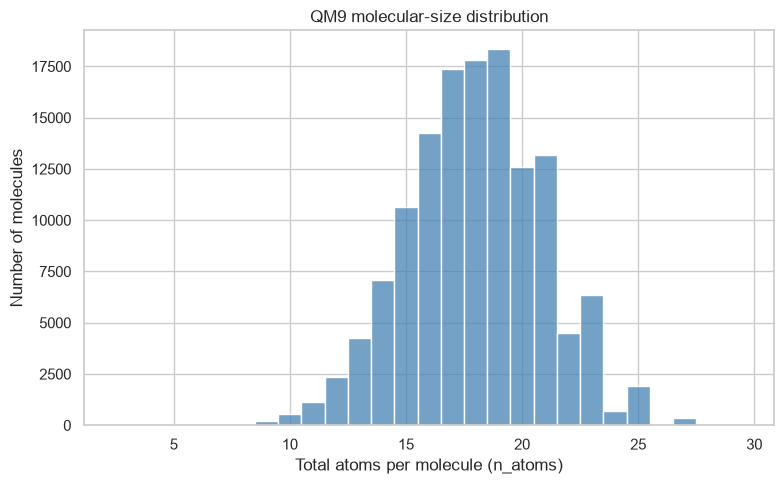

In [22]:
# 5.1 Distribution of the total atom count (n_atoms) per molecule.
n_atoms = qm9["n_atoms"]

print("n_atoms — summary")
print(f"  count   : {n_atoms.count():,}")
print(f"  min/max : {n_atoms.min()} / {n_atoms.max()}")
print(f"  mean    : {n_atoms.mean():.2f}")
print(f"  median  : {n_atoms.median():.0f}")
print(f"  mode    : {int(n_atoms.mode().iloc[0])}")
print(f"  std     : {n_atoms.std():.2f}")
print(f"  skew    : {n_atoms.skew():.2f}  (negative -> left-skewed)")

# Labelled histogram saved for the report (the full per-size breakdown is visible here).
fig, ax = plt.subplots()
sns.histplot(n_atoms, discrete=True, color="steelblue", ax=ax)
ax.set_xlabel("Total atoms per molecule (n_atoms)")
ax.set_ylabel("Number of molecules")
ax.set_title("QM9 molecular-size distribution")
fig.tight_layout()

fig_path = FIGURES / "eda_n_atoms_distribution.png"
fig.savefig(fig_path, dpi=150)
print(f"\nSaved figure -> {fig_path.relative_to(PROJECT_ROOT).as_posix()}")
plt.show()

**What we find.** Molecular size is **tightly clustered and roughly symmetric**, not
left-skewed as loosely guessed above. The count rises smoothly to a broad peak at
**17–19 atoms** (each ~13% of the dataset) and falls off on both sides — mean `17.98`,
median `18`, mode `19`, and a near-zero skew of `−0.03`. With a standard deviation of
only `~2.95` atoms, **over 90% of molecules fall in the 14–23 range**; the documented
extremes (3-atom molecules at one end, 29 at the other) together account for a tiny
fraction of a percent.

One quirk stands out in the histogram: the per-size counts are **not** monotonic
around the peak — e.g. 21 atoms outnumbers 20, and 23 outnumbers 22, giving the bars a
saw-tooth look. This even/odd zig-zag is a parity effect of hydrogen saturation
(adding one heavy atom often changes the H count by more than one), not a data problem.

**Takeaway for later sections.** Because size varies so little, `n_atoms` alone will
explain only part of the spread in the *extensive* properties; the per-molecule
*chemistry* (which atoms, which bonds) must drive the rest. We return to this when we
examine property–property and property–size relationships.

### 5.2 Rotational constants A, B, C — what *shape* is each molecule?

The next three columns — `A`, `B`, `C` (in gigahertz) — are the molecule's **rotational
constants**. Plotted raw they are useless to anyone: `A` alone spans `0` to ~`620,000`
GHz while `C` never exceeds ~`283`, so a plain histogram is just an uninterpretable spike.
They become *interesting* only once we read what they physically mean.

**The intuition.** A molecule drifting in space tumbles end-over-end like a thrown object.
`A`, `B`, `C` measure how fast it spins about its three mutually perpendicular axes. The
key fact: spin speed is set by how the molecule's mass is spread out — mass hugging an axis
spins fast (large constant), mass flung far from an axis spins slowly (small constant), the
same reason a figure skater speeds up by pulling their arms in. So the *three* numbers
together secretly encode the one thing a layman actually cares about: the molecule's
**shape**. By convention they come pre-sorted `A ≥ B ≥ C` (verified for all 133,885).

**"But a thrown ball doesn't always tumble."** Exactly — a well-thrown American football
flies in a clean spiral and barely tumbles at all, so why does *every* molecule still carry
three of these numbers? Because `A`, `B`, `C` are **not a recording of any actual motion**;
they are baked-in properties of the molecule's *mass layout*, computed straight from where
its atoms sit. They state how hard it is to spin the object about each of its three axes —
its built-in "spin personality" — whether or not it happens to be spinning right now. That
football still *has* all three numbers in mid-spiral; throwing it as a spiral just means it
is momentarily using only one of them. (In practice molecules are never truly still — at any
temperature above absolute zero they are perpetually jostled into rotation — but even a
perfectly motionless molecule would carry the very same three constants.)

**Collapsing three numbers into one shape score.** Rather than plot three correlated
columns, we use the chemist's standard one-number summary — *Ray's asymmetry parameter*:

$$\kappa = \frac{2B - A - C}{A - C}$$

which runs from **κ = −1: a cigar / pencil (prolate)**, through **κ ≈ 0: a lopsided,
no-symmetry "potato"**, to **κ = +1: a frisbee / disc (oblate)**. One number, one axis,
easy to plot — and it directly answers *"is this molecule more like a pencil or a frisbee?"*

**Two special shapes get their own handling** (per the design discussion):

- **Rods — perfectly linear molecules.** A straight molecule has *no* meaningful spin about
  its long axis, so `A` is physically infinite and QM9 stores the sentinel **`A = 0`** (9
  molecules — all triple-bonded sticks like acetylene `C#C` and hydrogen cyanide `C#N`). We
  keep these **apart** as their own class; conceptually they are the ultimate cigars and sit
  exactly at the κ = −1 edge, so reporting them separately costs the plot nothing.
- **Balls — spherical tops (`A ≈ B ≈ C`).** Here the denominator `A − C → 0`, so κ is
  mathematically undefined (0/0): a sphere simply has no "long" or "flat" axis to report.
  These are rare, and we flag them separately rather than let a spurious 0/0 land in the
  κ ≈ 0 middle and masquerade as "maximally lopsided."

The cell below computes κ for the remaining (genuinely asymmetric) molecules, names a real
example of each shape class, and plots the κ distribution with plain-language labels.

Rotor-shape breakdown of QM9
  linear rods (A == 0)         :       9
  spherical tops (A ~ B ~ C)   :       9
  prolate / cigar   (kappa<0)  : 123,281  (92.1%)
  oblate  / frisbee (kappa>0)  :  10,586  (7.9%)
  median kappa                 : -0.75  (strongly prolate)

A real molecule for each shape:
  pencil / cigar (kappa -> -1) : mol    116  CC#CC#N
  frisbee / disc (kappa -> +1) : mol     47  C1CCC1
  spherical ball (A ~ B ~ C)   : mol      1  C
  linear rod (A == 0)          : mol      4  C#C

Saved figure -> reports/figures/eda_rotational_shape_kappa.png


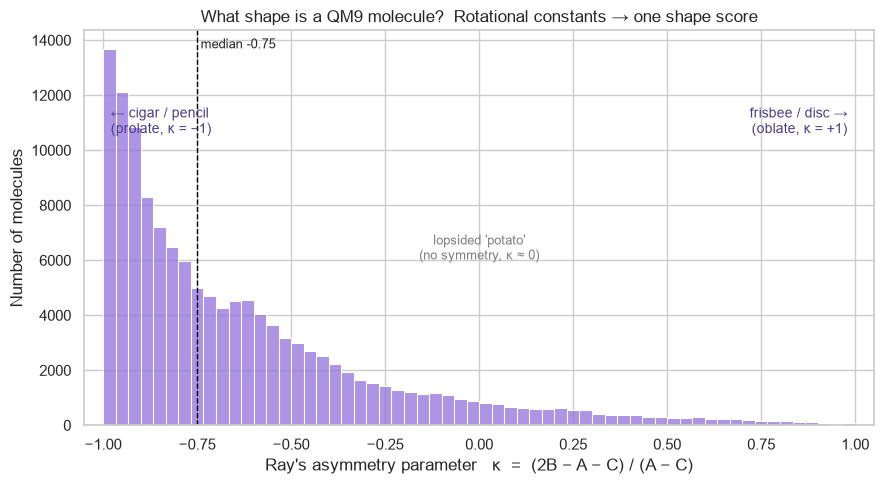

In [23]:
# 5.2 Rotational constants A, B, C -> a single "molecular shape" score.
# Physics: A >= B >= C are spin rates about the three principal axes, set by how the
# molecule's mass is spread out; their pattern encodes its shape. We collapse them into
# Ray's asymmetry parameter  kappa = (2B - A - C) / (A - C),  which runs from -1 (prolate
# / cigar) to +1 (oblate / frisbee). Two special classes are handled apart:
#   * linear "rods"      -> A stored as the sentinel 0 (no spin about the long axis)
#   * spherical "balls"  -> A ~ B ~ C, where kappa is 0/0 and physically undefined
A, B, C = qm9["A"], qm9["B"], qm9["C"]

is_linear = A == 0                                    # rods (A == 0 sentinel)
rel_spread = (A - C) / A.where(A > 0)                 # 0 -> a perfect ball
is_spherical = (~is_linear) & (rel_spread < 0.01)     # balls (A ~ B ~ C)

# kappa is only meaningful for genuinely asymmetric molecules (A > C, not a ball/rod).
shaped = (~is_linear) & (~is_spherical)
kappa = ((2 * B - A - C) / (A - C))[shaped]

smiles = qm9_identifiers["smiles_gdb17"]
def example(mol_id):
    return f"mol {mol_id:>6}  {smiles.loc[mol_id]}"

print("Rotor-shape breakdown of QM9")
print(f"  linear rods (A == 0)         : {int(is_linear.sum()):>7,}")
print(f"  spherical tops (A ~ B ~ C)   : {int(is_spherical.sum()):>7,}")
print(f"  prolate / cigar   (kappa<0)  : {int((kappa < 0).sum()):>7,}  ({(kappa < 0).mean():.1%})")
print(f"  oblate  / frisbee (kappa>0)  : {int((kappa > 0).sum()):>7,}  ({(kappa > 0).mean():.1%})")
print(f"  median kappa                 : {kappa.median():.2f}  (strongly prolate)")

print("\nA real molecule for each shape:")
print(f"  pencil / cigar (kappa -> -1) : {example(kappa.idxmin())}")
print(f"  frisbee / disc (kappa -> +1) : {example(kappa.idxmax())}")
print(f"  spherical ball (A ~ B ~ C)   : {example(rel_spread[is_spherical].idxmin())}")
print(f"  linear rod (A == 0)          : {example(A.index[is_linear][0])}")

# One annotated histogram of the shape score -- the layman's "pencil vs frisbee" picture.
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(kappa, bins=60, color="mediumpurple", ax=ax)
top = ax.get_ylim()[1]
ax.axvline(kappa.median(), color="black", linestyle="--", linewidth=1)
ax.text(kappa.median(), top * 0.98, f" median {kappa.median():.2f}", va="top", fontsize=9)
ax.set_xlim(-1.05, 1.05)
ax.set_xlabel("Ray's asymmetry parameter   κ  =  (2B − A − C) / (A − C)")
ax.set_ylabel("Number of molecules")
ax.set_title("What shape is a QM9 molecule?  Rotational constants → one shape score")
ax.annotate("← cigar / pencil\n(prolate, κ = −1)", xy=(-1, 0),
            xytext=(-0.98, top * 0.74), fontsize=10, color="darkslateblue", ha="left")
ax.annotate("frisbee / disc →\n(oblate, κ = +1)", xy=(1, 0),
            xytext=(0.98, top * 0.74), fontsize=10, color="darkslateblue", ha="right")
ax.annotate("lopsided 'potato'\n(no symmetry, κ ≈ 0)", xy=(0, 0),
            xytext=(0.0, top * 0.42), fontsize=9, color="gray", ha="center")
fig.tight_layout()

fig_path = FIGURES / "eda_rotational_shape_kappa.png"
fig.savefig(fig_path, dpi=150)
print(f"\nSaved figure -> {fig_path.relative_to(PROJECT_ROOT).as_posix()}")
plt.show()

**What we find.** QM9 molecules are overwhelmingly **elongated, cigar-leaning shapes.**
About **92%** are prolate (κ < 0) and only ~8% are oblate (κ > 0); the median κ ≈ −0.75
sits deep in pencil territory, with a pronounced pile-up right at the **κ = −1** edge
(near-perfect prolate "symmetric tops"). Frisbee-like discs (κ → +1) are comparatively
rare — the clearest example being the flat four-membered ring cyclobutane (`C1CCC1`).

**Why this makes chemical sense.** With at most nine heavy atoms, the lowest-energy way to
assemble them is usually a chain or a lightly-branched backbone — intrinsically pencil-like
— rather than a flat, fused, disc-shaped polycyclic system, which needs more atoms. The two
special classes bracket the picture: the **9 linear rods** (`C#C`, `C#N`, the
cyanoacetylenes) are the limiting cigars, and the rare **spherical "balls"** — the textbook
case being methane (CH₄, SMILES `C`), a perfectly tetrahedral spinning top — are the only
molecules with no long or flat axis at all.

**Takeaway for later sections.** Shape is not just trivia: rotational constants are exactly
what microwave spectroscopy measures to *identify* a molecule, and a molecule's anisotropy
correlates with properties such as the polarizability (`alpha`) we examine later. The strong
prolate bias is also a sampling fact worth remembering — QM9 is rich in chains, sparse in
discs.


## 6. Visualization

_Placeholder_ — distribution plots, correlations, and property comparisons (saved to
`reports/figures/`).

## 7. Findings & Communication

_Placeholder_ — narrative summary of insights, with academic citations and a References
section, and how this workflow connects to future ML / Deep Learning work.